In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import os
import time

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

# --- Configuration ---
NUM_CLIENTS = 10
NUM_ROUNDS = 50
LEARNING_RATE = 0.01
BATCH_SIZE = 512
K_FIXED = 5 # Fixed number of local epochs
ALPHA_VALUES = [100, 1, 0.2, 0.05] # Dirichlet distribution parameter
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Running on device: {DEVICE}")

Running on device: cuda


### Step 2: Model and Data Preparation for CIFAR-10

We define a new CNN suitable for the 3-channel, 32x32 images of CIFAR-10. We also create a function to partition the dataset using a Dirichlet distribution, which will be the core of our experiment.

In [2]:
# --- Model Definition for CIFAR-10 ---
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super(CIFAR_CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(8 * 8 * 32, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 8 * 8 * 32)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

def get_params_vec(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

# --- Data Partitioning Function ---
def dirichlet_partition_data(dataset, num_clients, alpha, batch_size):
    num_classes = len(dataset.classes)
    data_indices = list(range(len(dataset)))
    class_indices = [np.where(np.array(dataset.targets) == i)[0] for i in range(num_classes)]

    client_indices = [[] for _ in range(num_clients)]
    
    # For each class, distribute its data among clients based on Dirichlet proportions
    for c_indices in class_indices:
        proportions = np.random.dirichlet([alpha] * num_clients)
        num_samples_for_class = (proportions * len(c_indices)).astype(int)
        
        # Handle rounding errors to ensure all samples are assigned
        rem = len(c_indices) - num_samples_for_class.sum()
        for i in range(rem):
            num_samples_for_class[i % num_clients] += 1

        # Assign indices
        start = 0
        for i in range(num_clients):
            end = start + num_samples_for_class[i]
            client_indices[i].extend(c_indices[start:end])
            start = end
            
    # Create DataLoaders
    client_loaders = []
    for indices in client_indices:
        client_dataset = Subset(dataset, indices)
        loader = DataLoader(client_dataset, batch_size=batch_size, shuffle=True)
        client_loaders.append(loader)
        
    return client_loaders

# --- Data Loading and Transformation for CIFAR-10 ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

full_train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

### Step 3: Helper Functions for Training and Evaluation

These functions are reused from Task 2, with a small modification to `calculate_divergence` for efficiency.

In [3]:
def train_client(model, data_loader, lr, local_epochs):
    """Performs local training on a client."""
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(local_epochs):
        for data, target in data_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
    return model.state_dict()

def evaluate_model(model, test_loader):
    """Evaluates the global model on the test set."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return 100 * correct / total

def calculate_divergence(global_model_params_t, local_model_updates):
    """Calculates the weight divergence (client drift)."""
    divergences = []
    global_vec_cpu = global_model_params_t.cpu()
    for state_dict in local_model_updates:
        # The order of state_dict.values() is guaranteed in Python 3.7+
        local_vec = torch.cat([p.data.view(-1) for p in state_dict.values()]).cpu()
        diff_norm = torch.linalg.norm(global_vec_cpu - local_vec)
        divergences.append(diff_norm.item())
    
    return np.mean(divergences)

### Step 4: Core FedAvg Training Loop for Heterogeneous Data

This function orchestrates the FedAvg process. It's now parameterized to accept the `client_loaders` and the `model_class` to allow for different data distributions and model architectures.

In [4]:
def run_fedavg(num_rounds, local_epochs, client_sampling_fraction, client_loaders, model_class):
    # Initialize global model
    global_model = model_class().to(DEVICE)

    accuracies = []
    drifts = []
    num_total_clients = len(client_loaders)
    num_selected_clients = int(num_total_clients * client_sampling_fraction)

    for round_num in range(num_rounds):
        start_time = time.time()
        
        # Client selection
        selected_client_indices = np.random.choice(range(num_total_clients), num_selected_clients, replace=False)
        
        local_model_updates = []
        
        # Store the global model weights from the start of the round for drift calculation
        global_model_params_t = get_params_vec(global_model).clone().detach()

        # --- Local Training on Selected Clients ---
        for client_idx in selected_client_indices:
            local_model = model_class().to(DEVICE)
            local_model.load_state_dict(global_model.state_dict()) # Broadcast
        
            # Skip clients with no data
            if len(client_loaders[client_idx].dataset) == 0:
                continue

            updated_params = train_client(
                model=local_model,
                data_loader=client_loaders[client_idx],
                lr=LEARNING_RATE,
                local_epochs=local_epochs
            )
            local_model_updates.append(updated_params)

        # Check if any clients were trained
        if not local_model_updates:
            print(f"Round {round_num+1}/{num_rounds} | No clients trained in this round. Skipping aggregation.")
            accuracies.append(evaluate_model(global_model, test_loader))
            drifts.append(0) # No drift if no training
            continue

        # --- Calculate Client Drift ---
        drift = calculate_divergence(global_model_params_t, local_model_updates)
        drifts.append(drift)

        # --- Server Aggregation ---
        global_state_dict = global_model.state_dict()
        for key in global_state_dict.keys():
            # Simple average since client sampling is uniform
            sum_of_weights = torch.stack([update[key].float() for update in local_model_updates], 0).sum(0)
            global_state_dict[key] = sum_of_weights / len(local_model_updates)
        
        global_model.load_state_dict(global_state_dict)
        
        # --- Global Model Evaluation ---
        accuracy = evaluate_model(global_model, test_loader)
        accuracies.append(accuracy)
        
        round_time = time.time() - start_time
        print(f"Round {round_num+1}/{num_rounds} | Accuracy: {accuracy:.2f}% | Drift: {drift:.2f} | Time: {round_time:.2f}s")
        
    return accuracies, drifts

### Step 5: Experiment - Varying Data Heterogeneity (α)

We now run the main experiment. We loop through our chosen `α` values, partition the CIFAR-10 dataset for each, and run FedAvg with `K=5` and full client participation. We then plot the results to compare how different levels of label skew affect accuracy and drift.

In [5]:
import pickle
import os

results_alpha = {}

os.makedirs('task3/figures', exist_ok=True)
os.makedirs('task3/results', exist_ok=True)

for alpha in ALPHA_VALUES:
    print(f"\n--- Processing experiment for alpha = {alpha} ---")
    result_filename = f'task3/results/results_alpha_{alpha}.pkl'

    if os.path.exists(result_filename):
        print(f"Loading existing results for alpha = {alpha} from {result_filename}")
        with open(result_filename, 'rb') as f:
            results_alpha[alpha] = pickle.load(f)
    else:
        print(f"No existing results found for alpha = {alpha}. Running experiment...")
        client_loaders = dirichlet_partition_data(
            dataset=full_train_dataset, 
            num_clients=NUM_CLIENTS, 
            alpha=alpha, 
            batch_size=BATCH_SIZE
        )

        accuracies, drifts = run_fedavg(
            num_rounds=NUM_ROUNDS,
            local_epochs=K_FIXED,
            client_sampling_fraction=1.0,
            client_loaders=client_loaders,
            model_class=CIFAR_CNN
        )

        results_alpha[alpha] = {'accuracies': accuracies, 'drifts': drifts}

        print(f"Saving results for alpha = {alpha} to {result_filename}")
        with open(result_filename, 'wb') as f:
            pickle.dump(results_alpha[alpha], f)


--- Processing experiment for alpha = 100 ---
No existing results found for alpha = 100. Running experiment...
Round 1/50 | Accuracy: 16.34% | Drift: 0.14 | Time: 55.69s
Round 2/50 | Accuracy: 23.76% | Drift: 0.20 | Time: 55.41s
Round 3/50 | Accuracy: 28.34% | Drift: 0.25 | Time: 55.48s
Round 4/50 | Accuracy: 30.93% | Drift: 0.22 | Time: 56.26s
Round 5/50 | Accuracy: 34.73% | Drift: 0.21 | Time: 55.35s
Round 6/50 | Accuracy: 35.62% | Drift: 0.19 | Time: 55.52s
Round 7/50 | Accuracy: 37.74% | Drift: 0.18 | Time: 54.88s
Round 8/50 | Accuracy: 39.61% | Drift: 0.18 | Time: 54.38s
Round 9/50 | Accuracy: 40.85% | Drift: 0.17 | Time: 54.66s
Round 10/50 | Accuracy: 41.60% | Drift: 0.17 | Time: 54.91s
Round 11/50 | Accuracy: 43.14% | Drift: 0.17 | Time: 54.84s
Round 12/50 | Accuracy: 44.49% | Drift: 0.16 | Time: 54.76s
Round 13/50 | Accuracy: 45.17% | Drift: 0.16 | Time: 55.82s
Round 14/50 | Accuracy: 46.06% | Drift: 0.16 | Time: 55.46s
Round 15/50 | Accuracy: 47.14% | Drift: 0.16 | Time: 55.8

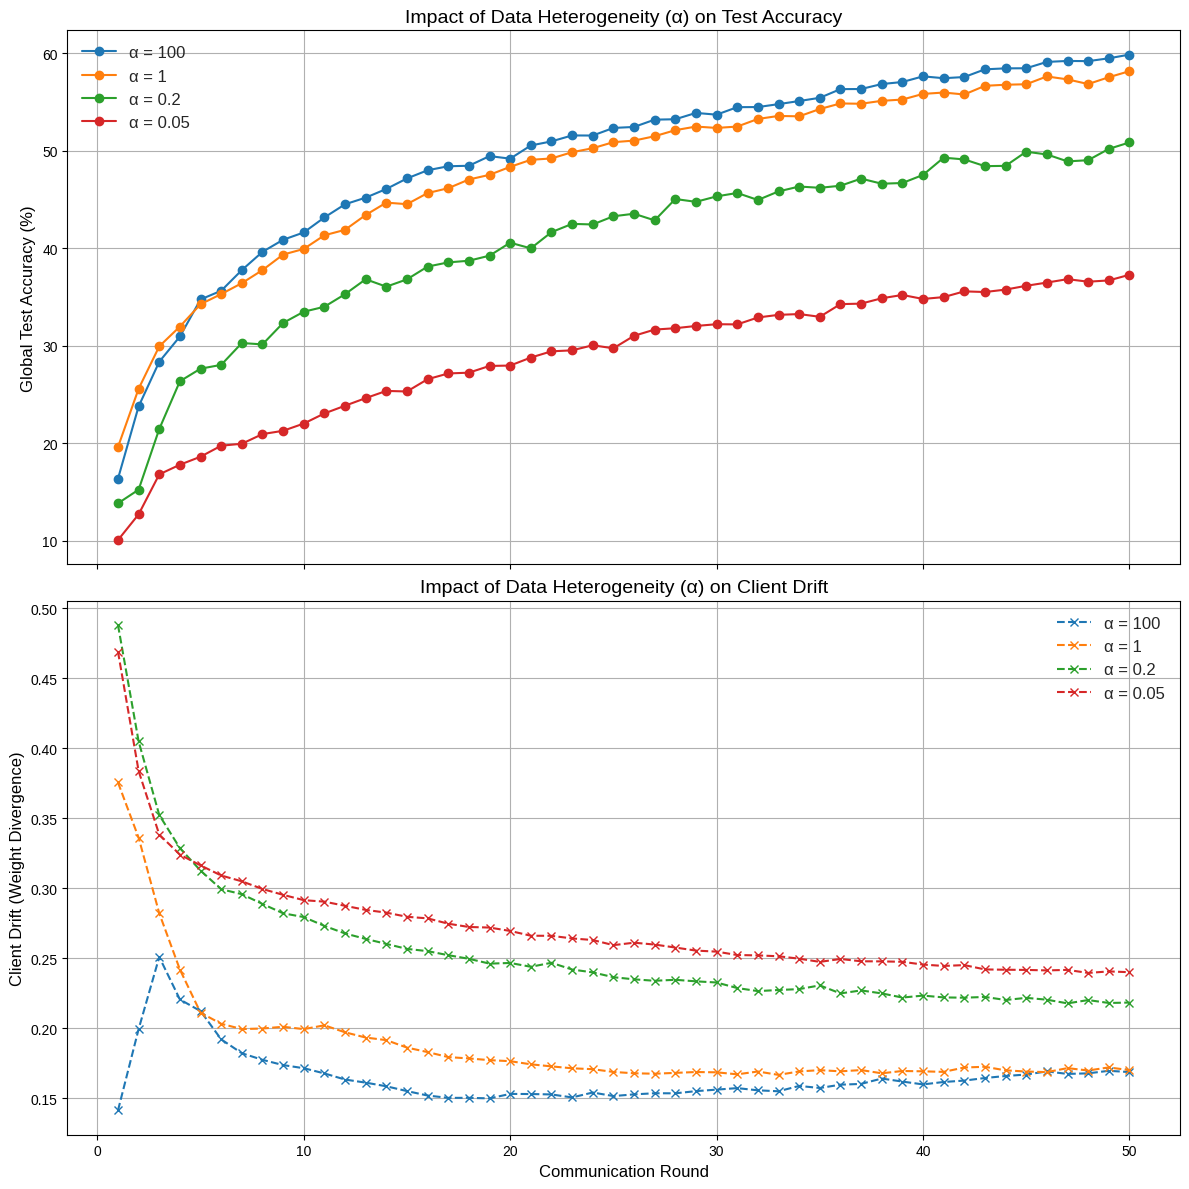

In [6]:
# --- Plotting for Experiment ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)
plt.style.use('seaborn-v0_8-whitegrid')

# Plot Test Accuracy
for alpha, result in results_alpha.items():
    ax1.plot(range(1, NUM_ROUNDS + 1), result['accuracies'], marker='o', linestyle='-', label=f'α = {alpha}')
ax1.set_ylabel("Global Test Accuracy (%)", fontsize=12)
ax1.set_title("Impact of Data Heterogeneity (α) on Test Accuracy", fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True)

# Plot Client Drift
for alpha, result in results_alpha.items():
    ax2.plot(range(1, NUM_ROUNDS + 1), result['drifts'], marker='x', linestyle='--', label=f'α = {alpha}')
ax2.set_xlabel("Communication Round", fontsize=12)
ax2.set_ylabel("Client Drift (Weight Divergence)", fontsize=12)
ax2.set_title("Impact of Data Heterogeneity (α) on Client Drift", fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True)

plt.tight_layout()
plt.savefig('task3/figures/impact_of_alpha.png')
plt.show()